# Validate Trained LightGBM Model Notebook
This notebook evaluates your custom trained EMBER model. It runs batched predictions on the validation set, calculates accuracy/AUC, and visuals the performance.

In [1]:
import os
import sys
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, precision_score, recall_score, f1_score

# Display plots inline
%matplotlib inline

# Add local venv site-packages to path so thrember can be imported
venv_site_packages = os.path.join(os.getcwd(), "venv", "Lib", "site-packages")
if os.path.exists(venv_site_packages):
    sys.path.append(venv_site_packages)

try:
    from thrember.features import PEFeatureExtractor
    print("Features extractor imported successfully.")
except ImportError:
    print("Warning: 'thrember' not found. Will use default feature dimension (2381).")
    class PEFeatureExtractor:
        dim = 2381

c:\Users\him\ember2024_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features extractor imported successfully.


### 1. Setup Dataset & Configuration

In [2]:
def setup_dataset(dataset_dir, model_filename="ember_model_tuned_full.txt"):
    print(f"Preparing to evaluate model from {dataset_dir}...")
    
    model_path = os.path.join(dataset_dir, model_filename)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Error: Model file not found at {model_path}")

    # Setup paths
    X_path = os.path.join(dataset_dir, "X_train.dat")
    y_path = os.path.join(dataset_dir, "y_train.dat")
    plots_dir = os.path.join(dataset_dir, "evaluation_plots")
    os.makedirs(plots_dir, exist_ok=True)
    
    # Get dimensions
    extractor = PEFeatureExtractor()
    ndim = extractor.dim
    
    if not os.path.exists(X_path):
         raise FileNotFoundError(f"Error: Data file not found at {X_path}")
         
    file_size = os.path.getsize(X_path)
    nrows = file_size // (ndim * 4)
    
    # Calculate Split (Last 10% is validation)
    train_nrows = int(nrows * 0.9)
    val_nrows = nrows - train_nrows
    val_start_idx = train_nrows
    
    print(f"Total rows in dataset: {nrows}")
    print(f"Validation set size: {val_nrows} samples (starts at index {val_start_idx})")
    print(f"Plots will be saved to: {plots_dir}")
    
    return model_path, plots_dir, X_path, y_path, nrows, ndim, val_start_idx, val_nrows

### 2. Batched Prediction Loop

In [3]:
def run_predictions(model_path, X_path, y_path, nrows, ndim, val_start_idx, val_nrows, batch_size=100000):
    
    # Load the model
    print(f"\nLoading model: {model_path}...")
    model = lgb.Booster(model_file=model_path)

    # Memory map the arrays
    X_memmap = np.memmap(X_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
    y_memmap = np.memmap(y_path, dtype=np.int32, mode="r", shape=(nrows,))

    print(f"Starting prediction loops in batches of {batch_size} (to protect RAM)...")
    
    y_true_all = []
    y_pred_prob_all = []

    for batch_start in range(val_start_idx, nrows, batch_size):
        batch_end = min(batch_start + batch_size, nrows)
        
        # Load batch into RAM
        X_batch = np.array(X_memmap[batch_start:batch_end])
        y_batch = np.array(y_memmap[batch_start:batch_end])
        
        # Filter unlabeled records (-1)
        valid_mask = y_batch != -1
        if not np.any(valid_mask):
            continue
            
        X_batch = X_batch[valid_mask]
        y_batch = y_batch[valid_mask]
        
        # Predict probabilities
        preds = model.predict(X_batch)
        
        y_true_all.extend(y_batch)
        y_pred_prob_all.extend(preds)
        
        print(f"  Processed batch {batch_start} - {batch_end}")

    y_true = np.array(y_true_all)
    y_pred_probs = np.array(y_pred_prob_all)
    
    return model, y_true, y_pred_probs

### 3. Metric Calculations & Visualizations

In [4]:
def evaluate_and_plot(model, y_val, y_pred_prob, plots_dir):
    if len(y_val) == 0:
        print("Error: No valid labels found to evaluate.")
        return
        
    # Convert probabilities to binary class labels based on a 0.5 threshold 
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\nExample Predictions (prob > 0.5): {y_pred[:10]}")
    print(f"Actual True Labels:               {y_val[:10]}")

    # Calculate core metrics
    auc = roc_auc_score(y_val, y_pred_prob)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print("-" * 30)
    print(f"Validation AUC:       {auc:.4f}")
    print(f"Validation Accuracy:  {acc:.4f}")
    print(f"Validation Precision: {prec:.4f}")
    print(f"Validation Recall:    {rec:.4f}")
    print(f"Validation F1 Score:  {f1:.4f}")
    print("-" * 30)

    # 1. ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc:.4f})', linewidth=2, color='darkorange')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    roc_save_path = os.path.join(plots_dir, 'roc_curve.png')
    plt.savefig(roc_save_path)
    print(f"Saved ROC Curve to {roc_save_path}")
    plt.show() # Render inline

    # 2. Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Benign', 'Malicious'], 
                yticklabels=['Benign', 'Malicious'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    
    cm_save_path = os.path.join(plots_dir, 'confusion_matrix.png')
    plt.savefig(cm_save_path)
    print(f"Saved Confusion Matrix to {cm_save_path}")
    plt.show() # Render inline

    # 3. Feature Importance
    plt.figure(figsize=(10, 8))
    ax = lgb.plot_importance(model, max_num_features=25, title='Top 25 Feature Importances', 
                             importance_type='split', figsize=(10, 8))
    plt.tight_layout()
    
    fi_save_path = os.path.join(plots_dir, 'feature_importance.png')
    plt.savefig(fi_save_path)
    print(f"Saved Feature Importances to {fi_save_path}")
    plt.show() # Render inline

### 4. Run Evaluation Pipeline

Preparing to evaluate model from Z:\ember2024_train_data...
Total rows in dataset: 5252000
Validation set size: 525200 samples (starts at index 4726800)
Plots will be saved to: Z:\ember2024_train_data\evaluation_plots

Loading model: Z:\ember2024_train_data\ember_model_tuned_full.txt...
Starting prediction loops in batches of 100000 (to protect RAM)...
  Processed batch 4726800 - 4826800
  Processed batch 4826800 - 4926800
  Processed batch 4926800 - 5026800
  Processed batch 5026800 - 5126800
  Processed batch 5126800 - 5226800
  Processed batch 5226800 - 5252000

Example Predictions (prob > 0.5): [0 0 1 1 1 1 0 1 0 0]
Actual True Labels:               [0 0 1 1 1 0 0 1 0 0]
------------------------------
Validation AUC:       0.8118
Validation Accuracy:  0.8104
Validation Precision: 0.8128
Validation Recall:    0.8065
Validation F1 Score:  0.8096
------------------------------
Saved ROC Curve to Z:\ember2024_train_data\evaluation_plots\roc_curve.png


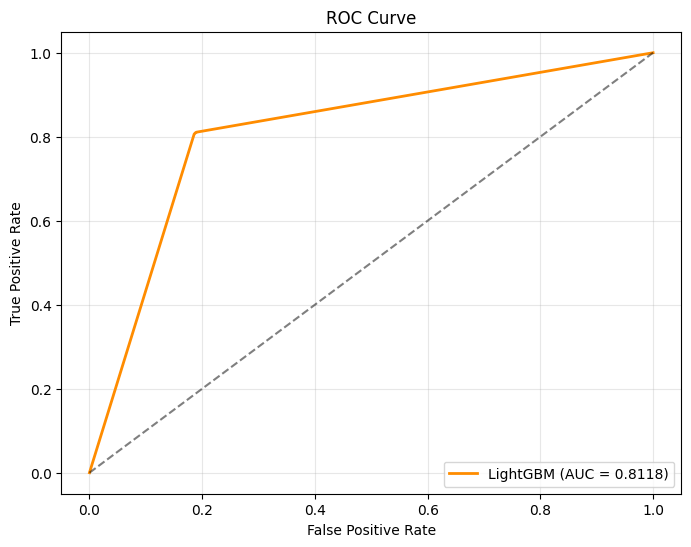

Saved Confusion Matrix to Z:\ember2024_train_data\evaluation_plots\confusion_matrix.png


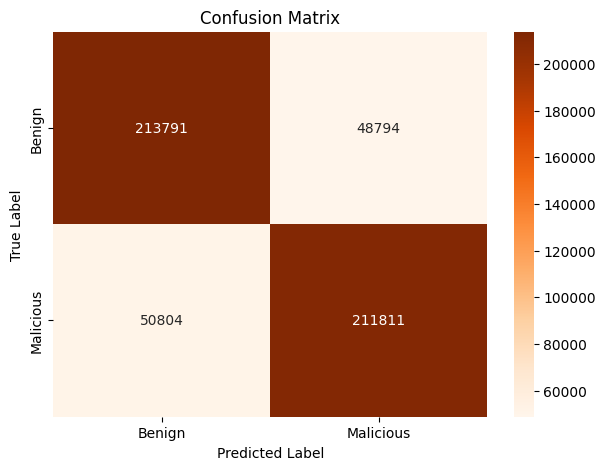

Saved Feature Importances to Z:\ember2024_train_data\evaluation_plots\feature_importance.png


<Figure size 1000x800 with 0 Axes>

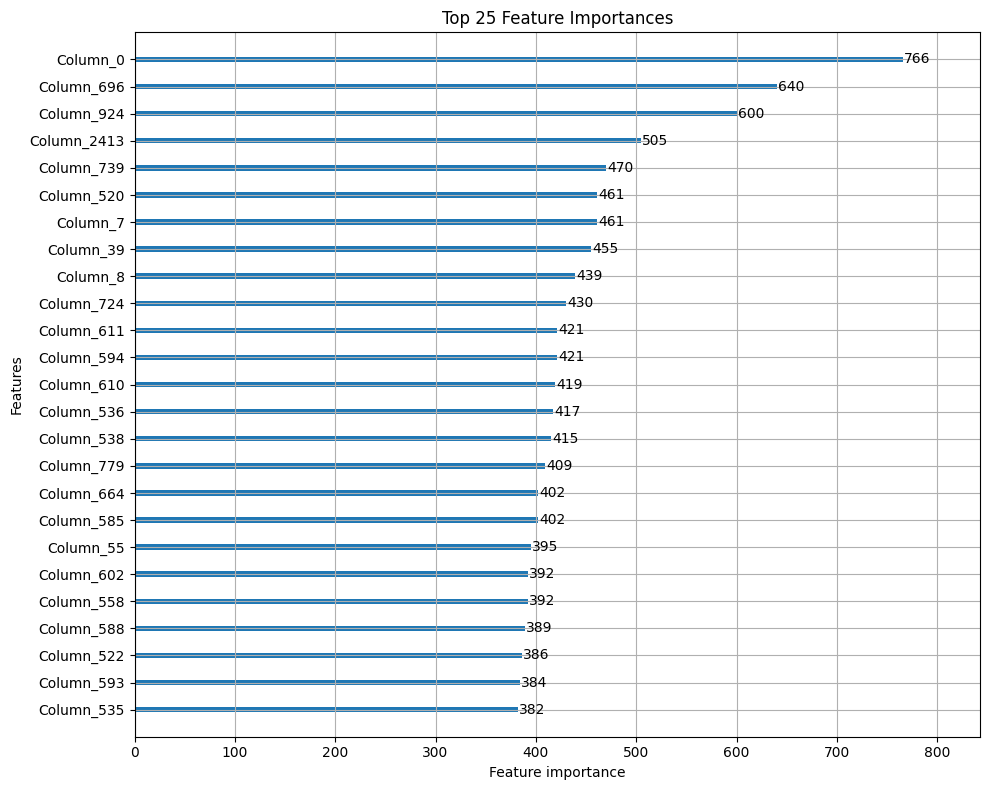


=> ✅ Evaluation pipeline complete.


In [5]:
# Set your path and desired model name here
DATASET_DIR = r"Z:\ember2024_train_data"
MODEL_FILENAME = "ember_model_tuned_full.txt" 

try:
    # 1. Setup paths
    model_path, plots_dir, X_path, y_path, nrows, ndim, val_start, val_nrows = setup_dataset(
        dataset_dir=DATASET_DIR, 
        model_filename=MODEL_FILENAME
    )
    
    # 2. Iterate and Predict
    model_obj, y_val, y_pred_prob = run_predictions(
        model_path, X_path, y_path, nrows, ndim, val_start, val_nrows, batch_size=100000
    )
    
    # 3. Grade & Visualize
    evaluate_and_plot(model_obj, y_val, y_pred_prob, plots_dir)
    
    print("\n=> ✅ Evaluation pipeline complete.")
    
except FileNotFoundError as e:
    print(e)